In [ ]:
from torch.utils.data import random_split
from neuralop.data.datasets import load_darcy_flow_small
import torch
from torch.utils.data import DataLoader
import copy

In [2]:
train_loader, test_loaders, data_processor = load_darcy_flow_small(
    n_train=1000,
    batch_size=64,
    n_tests=[50, 50],
    test_resolutions=[16, 32],
    test_batch_sizes=[32, 32],
)

Loading test db for resolution 16 with 50 samples 
Loading test db for resolution 32 with 50 samples 


In [3]:
train_ds = train_loader.dataset

train_darcy, train_quantile, calib_scale = random_split(
    train_ds,
    [700, 200, 100],
    generator=torch.Generator().manual_seed(0)
)

In [4]:
train_darcy_loader = DataLoader(
    train_darcy,
    batch_size=64,
    shuffle=True,
)

train_quantile_loader = DataLoader(
    train_quantile,
    batch_size=64,
    shuffle=True,
)

calib_scale_loader = DataLoader(
    calib_scale,
    batch_size=64,
    shuffle=False,
)

In [5]:
from fno_uq.models.fno import FNO2D
from fno_uq.train import train
from neuralop import H1Loss, LpLoss
from torch.optim import AdamW
from fno_uq.uq.conformal_quantile import ConformalQuantileRegressor

In [6]:
fno = FNO2D(
    in_channels=1,
    out_channels=1,
    hidden_channels=16,
    n_modes_x=8,
    n_modes_y=8,
    n_layers=4
)

In [7]:
h1loss = H1Loss(d=2)  # H1 loss includes gradient information
l2loss = LpLoss(d=2, p=2)
optimiser = AdamW(fno.parameters(), lr=1e-2, weight_decay=1e-4)
device = torch.device("cpu")

train_history = train(model=fno, train_loader=train_darcy_loader, test_loaders=test_loaders, loss_fn=l2loss, optimiser=optimiser, device=device, epochs=30)

/Users/tomstent/.virtualenvs/maths_env/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


epoch: 0, avg train loss: 39.315942001342776
epoch: 5, avg train loss: 10.755567779541016
epoch: 10, avg train loss: 7.931989598955427
epoch: 15, avg train loss: 6.4908594758169995
epoch: 20, avg train loss: 6.176172204698835
epoch: 25, avg train loss: 6.057804851531983


In [8]:
quantile_fno = copy.deepcopy(fno)

In [9]:
# WHY CANT WE DO alpha = 0.05
uq_fno = ConformalQuantileRegressor(fno, quantile_fno, alpha=0.1, device=device)

In [10]:
# The optimiser must be built over the quantile model's parameters:
# the base fno is frozen inside ConformalQuantileRegressor, so an optimiser
# over fno.parameters() would silently train nothing.
optimiser = AdamW(uq_fno.quantile_model.parameters(), lr=1e-2, weight_decay=1e-4)

uq_fno.fit_quantile(train_quantile_loader, optimiser=optimiser, epochs=50)

epoch: 0, avg train loss: 0.02100592777132988
epoch: 5, avg train loss: 0.012314336616545915
epoch: 10, avg train loss: 0.010599824972450734
epoch: 15, avg train loss: 0.00795417807996273
epoch: 20, avg train loss: 0.006274332217872143
epoch: 25, avg train loss: 0.0053303162753582
epoch: 30, avg train loss: 0.005017175879329443
epoch: 35, avg train loss: 0.004859281294047832
epoch: 40, avg train loss: 0.004671200942248106
epoch: 45, avg train loss: 0.004377538096159697


In [30]:
uq_fno.conformal_calibrate(calib_scale_loader, delta=0.05)
print(f"conformal scale factor: {uq_fno.scale_factor:.4f}")

metrics16 = uq_fno.evaluate(test_loaders[16])
metrics32 = uq_fno.evaluate(test_loaders[32])

print(metrics16["calibration_percentage"])
print(metrics32["calibration_percentage"])
print(metrics16["coverage"].mean())
print(metrics32["coverage"].mean())

conformal scale factor: 5.0169


/Users/tomstent/.virtualenvs/maths_env/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


1.0
1.0
0.998359375
0.98865234375


In [32]:
import matplotlib.pyplot as plt
import numpy as np
import random

dim = 16
batch = next(iter(test_loaders[dim]))
x = batch["x"]
y = batch["y"]

/Users/tomstent/.virtualenvs/maths_env/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


/var/folders/1s/kw07rc7x4h38919n18zshh740000gn/T/ipykernel_11626/4232599209.py:54: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


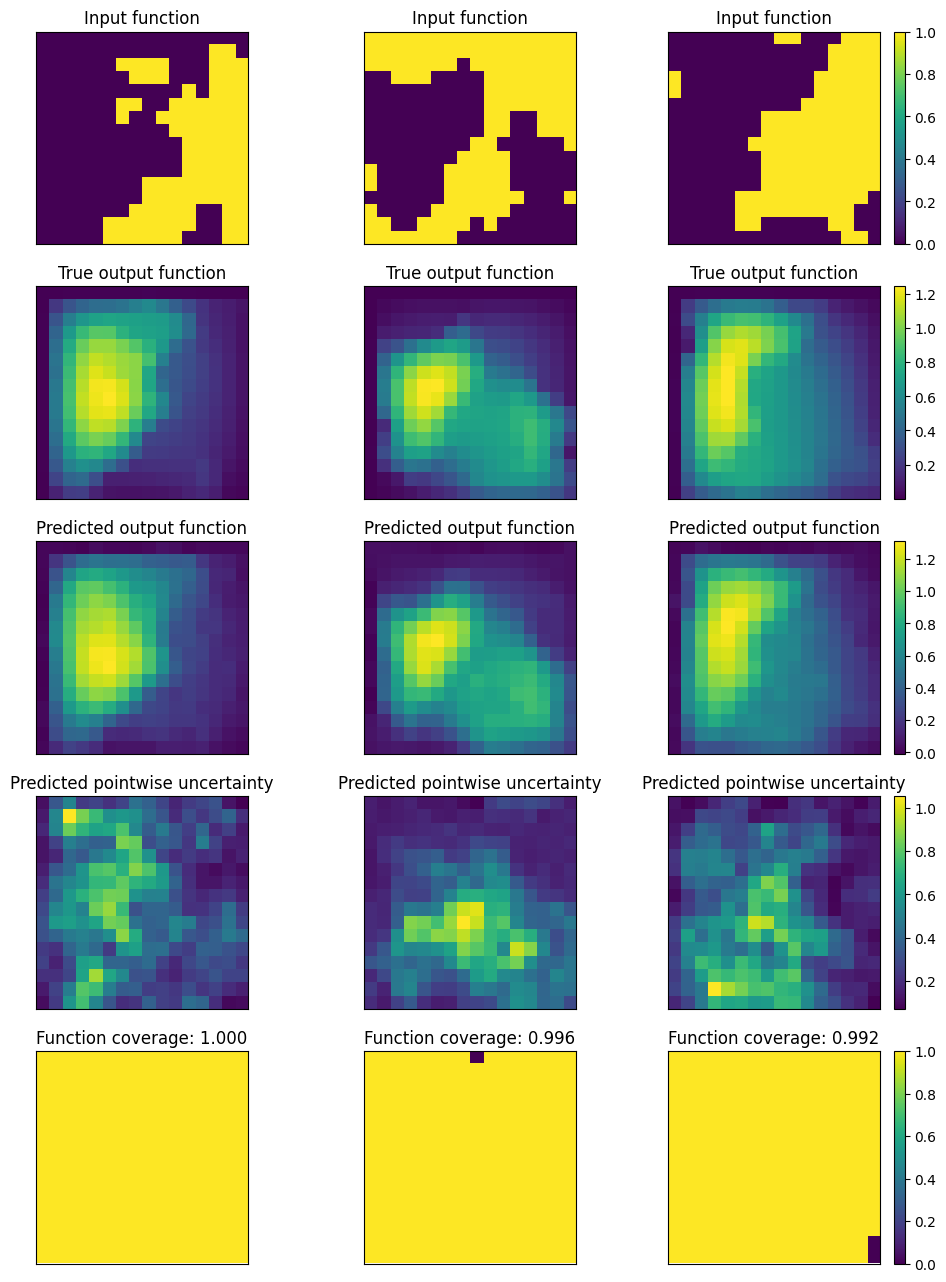

In [41]:
test_indices = random.sample(range(32), 3)
ims = [None] * 5

fig, axes = plt.subplots(5, 3, figsize=(12, 16))
for col_num, idx in enumerate(test_indices):

    a = x[idx:idx+1]
    u = y[idx:idx+1]

    u_pred, u_radius = uq_fno.predict_interval(a)

    # plot input
    ims[0] = axes[0, col_num].imshow(a.reshape(dim, dim))
    axes[0, col_num].set_title("Input function")
    axes[0, col_num].set_xticks([])
    axes[0, col_num].set_yticks([])
    
    # plot true output
    ims[1] = axes[1, col_num].imshow(u.reshape(dim, dim))
    axes[1, col_num].set_title("True output function")
    axes[1, col_num].set_xticks([])
    axes[1, col_num].set_yticks([])

    # plot predicted output
    ims[2] = axes[2, col_num].imshow(u_pred.reshape(dim, dim))
    axes[2, col_num].set_title("Predicted output function")
    axes[2, col_num].set_xticks([])
    axes[2, col_num].set_yticks([])

    # plot uncertainty
    ims[3] = axes[3, col_num].imshow(u_radius.reshape(dim, dim))
    axes[3, col_num].set_title("Predicted pointwise uncertainty")
    axes[3, col_num].set_xticks([])
    axes[3, col_num].set_yticks([])

    # plot coverage
    u_error_true = torch.abs(u - u_pred)
    coverage = (u_radius >= u_error_true).int()
    coverage_ratio = coverage.float().mean().item()

    ims[4] = axes[4, col_num].imshow(
        coverage.squeeze(),
        vmin=0,
        vmax=1
    )
    axes[4, col_num].set_title(f"Function coverage: {coverage_ratio:.3f}")
    axes[4, col_num].set_xticks([])
    axes[4, col_num].set_yticks([])

# add one colorbar per row, anchored to the rightmost axis
for row, im in enumerate(ims):
    fig.colorbar(im, ax=axes[row, -1])

fig.show()
